# 🔬 Notebook 03 — Aprendizaje No Supervisado
## PCA + K-Means · NHANES 2015-2016 (con Data Augmentation) · Autor: Álvaro

**Objetivo:** Descubrir **fenotipos o perfiles metabólicos** ocultos en la población adulta de NHANES, utilizando técnicas de aprendizaje no supervisado.

### ¿Por qué No Supervisado?
A diferencia de la clasificación supervisada (Notebook 04), aquí **no usamos la etiqueta** `IS_LONGEVO`.  
El propósito es que el algoritmo encuentre agrupaciones naturales basándose exclusivamente en los biomarcadores de salud. Esto nos permite:
- Identificar perfiles de riesgo que el negocio no había definido a priori.
- Validar si los clusters descubiertos coinciden con la longevidad real.
- Generar "segmentos de pacientes" útiles para la app de Edad Biológica.

### Pipeline:
1. PCA (Análisis de Componentes Principales) → Reducción de dimensionalidad
2. K-Means → Agrupamiento en K clusters
3. Validación: Método del Codo + Silhouette Score
4. Interpretación de centroides → Perfiles de salud

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
})

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

Usamos el dataset generado en el Notebook 02, que ya está:
- Libre de nulos (imputación con KNNImputer y SimpleImputer)
- Con variables categóricas codificadas (One-Hot Encoding)
- Con variables numéricas escaladas (StandardScaler)

> **Importante:** PCA y K-Means son sensibles a la escala de las variables, por eso es indispensable usar datos escalados.
> **Nota:** Se eliminan `CICLO_ORIGEN` e `IS_LONGEVO` de las features para que K-Means no tenga acceso a información que queremos descubrir.

In [2]:
# Cargar datos procesados
DATA_PATH = '../data/02_intermediate/nhanes_2015_procesado.csv'
META_PATH = '../data/02_intermediate/metadata_preprocesamiento.json'

df = pd.read_csv(DATA_PATH)

# Cargar metadatos (con fallback si el JSON no existe o está corrupto)
try:
    with open(META_PATH, 'r') as f:
        meta = json.load(f)
    print('📝 Metadatos cargados desde JSON.')
except (FileNotFoundError, json.JSONDecodeError):
    print('⚠️ JSON de metadatos no disponible. Derivando info del CSV...')
    cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO', 'CICLO_ORIGEN']
    meta = {
        'todas_las_features': [c for c in df.columns if c not in cols_excluir],
    }

# Eliminar CICLO_ORIGEN si existe (viene del data augmentation)
if 'CICLO_ORIGEN' in df.columns:
    print(f'🗑️ Eliminando CICLO_ORIGEN del dataset (solo para trazabilidad, no para modelado).')
    df = df.drop(columns=['CICLO_ORIGEN'])

print(f'📦 Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Nulos: {df.isnull().sum().sum()}')
df.head(3)

📝 Metadatos cargados desde JSON.
📦 Dataset cargado: 10,043 filas × 41 columnas
   Nulos: 0


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_5,DMDEDUC2_7,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,83732.0,62.0,-0.514928,-0.440763,1.329418,0.784963,1.954133,-0.172424,0.066934,1.443243,...,1,0,0,0,0,0,0,0,0,0
1,83733.0,53.0,-1.118221,-1.037901,-0.749542,0.563483,0.629827,0.294223,0.510994,0.046600,...,0,0,0,0,1,0,0,0,0,0
2,83734.0,78.0,-0.514928,-0.440763,-0.620877,0.211127,0.498408,-0.016875,1.072599,-0.585841,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# ── Preparar la matriz de features (X) ─────────────────────────────────
# Excluimos SEQN (ID), RIDAGEYR (target de regresión) e IS_LONGEVO (target de clasificación)
# PCA se aplica SOLO sobre las features, no sobre las variables objetivo.

cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
feature_cols = [c for c in df.columns if c not in cols_excluir]

X = df[feature_cols].values
print(f'📐 Matriz de features X: {X.shape}')
print(f'   Columnas: {feature_cols}')

📐 Matriz de features X: (10043, 38)
   Columnas: ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS', 'LBXTC', 'LBXGLU', 'RIAGENDR_2', 'RIDRETH3_2', 'RIDRETH3_3', 'RIDRETH3_4', 'RIDRETH3_6', 'RIDRETH3_7', 'DMDEDUC2_2', 'DMDEDUC2_3', 'DMDEDUC2_4', 'DMDEDUC2_5', 'DMDEDUC2_7', 'DMDEDUC2_9', 'DMDMARTL_2', 'DMDMARTL_3', 'DMDMARTL_4', 'DMDMARTL_5', 'DMDMARTL_6', 'DMDMARTL_77', 'DMDMARTL_99']


## 3. PCA — Análisis de Componentes Principales

### ¿Por qué PCA?
- **Reducción de dimensionalidad:** Con ~37 features, la visualización directa es imposible. PCA nos permite proyectar los datos en 2-3 dimensiones conservando la mayor varianza posible.
- **Eliminación de ruido:** Los componentes menores (que explican poca varianza) suelen capturar ruido, no señal real.
- **Mejora de K-Means:** En espacios de alta dimensionalidad, las distancias euclidianas (que usa K-Means) se vuelven menos informativas ("maldición de la dimensionalidad"). PCA mitiga este efecto.

Primero, aplicamos PCA **completo** para ver cuánta varianza explica cada componente.

In [4]:
# ── PCA completo (todos los componentes) ───────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Tabla de varianza por componente
df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza Explicada (%)': (varianza_explicada * 100).round(2),
    'Varianza Acumulada (%)': (varianza_acumulada * 100).round(2)
})

print('📊 Varianza explicada por componente (primeros 10):')
df_varianza.head(10)

📊 Varianza explicada por componente (primeros 10):


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,20.64,20.64
1,PC2,17.19,37.82
2,PC3,12.21,50.04
3,PC4,11.05,61.09
4,PC5,7.45,68.54
5,PC6,4.81,73.35
6,PC7,4.49,77.84
7,PC8,4.40,82.24
8,PC9,3.89,86.13
9,PC10,1.80,87.94


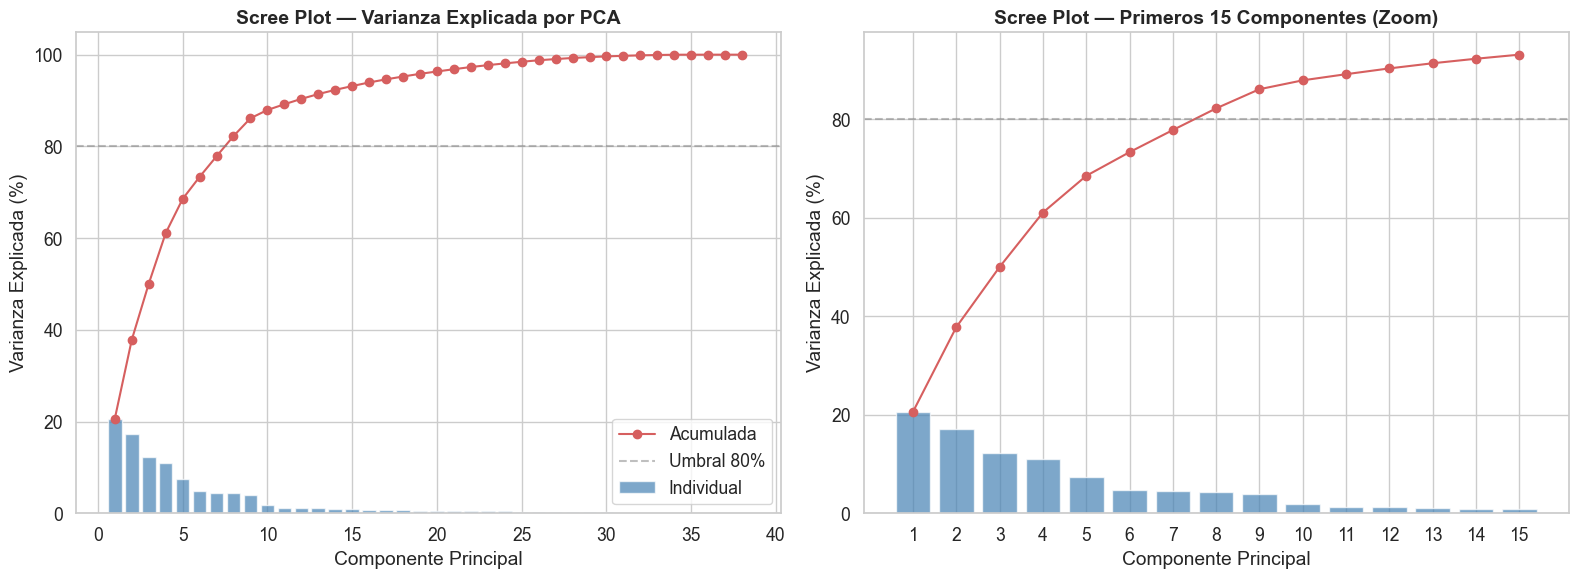


🎯 Componentes necesarios para ≥80% de varianza: 8


In [5]:
# ── Gráfico de varianza explicada ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
ax1.bar(range(1, len(varianza_explicada)+1), varianza_explicada * 100, 
        alpha=0.7, color='steelblue', label='Individual')
ax1.plot(range(1, len(varianza_explicada)+1), varianza_acumulada * 100, 
         'ro-', label='Acumulada')
ax1.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='Umbral 80%')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_title('Scree Plot — Varianza Explicada por PCA')
ax1.legend()

# Zoom en los primeros 15 componentes
n_zoom = min(15, len(varianza_explicada))
ax2.bar(range(1, n_zoom+1), varianza_explicada[:n_zoom] * 100, 
        alpha=0.7, color='steelblue')
ax2.plot(range(1, n_zoom+1), varianza_acumulada[:n_zoom] * 100, 'ro-')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Componente Principal')
ax2.set_ylabel('Varianza Explicada (%)')
ax2.set_title(f'Scree Plot — Primeros {n_zoom} Componentes (Zoom)')
ax2.set_xticks(range(1, n_zoom+1))

plt.tight_layout()
plt.savefig('../data/08_reporting/03_pca_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Seleccionar componentes que explican >= 80% de la varianza
n_components_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f'\n🎯 Componentes necesarios para ≥80% de varianza: {n_components_80}')

## 4. K-Means — Método del Codo + Silhouette Score

### ¿Por qué K-Means?
Es el algoritmo de clustering más interpretable y eficiente. Sus centroides representan el "paciente promedio" de cada grupo, lo que facilita la interpretación clínica.

### ¿Cómo elegir K?
Combinamos dos técnicas:
1. **Método del Codo:** Buscamos el punto donde la inercia (WCSS) deja de disminuir significativamente.
2. **Silhouette Score:** Mide la calidad de la separación entre clusters (más alto = mejor).

In [6]:
# ── Aplicar PCA con el número óptimo de componentes ───────────────────
# Usamos los componentes que explican ≥80% de varianza para K-Means
pca = PCA(n_components=n_components_80, random_state=42)
X_pca = pca.fit_transform(X)

print(f'📐 Dimensionalidad reducida: {X.shape[1]} → {X_pca.shape[1]} componentes')
print(f'   Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

📐 Dimensionalidad reducida: 38 → 8 componentes
   Varianza explicada total: 82.2%


In [7]:
# ── Método del Codo + Silhouette Score ─────────────────────────────────
K_range = range(2, 11)
inertias = []
silhouettes = []

print('⏳ Evaluando K de 2 a 10...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca, labels)
    silhouettes.append(sil)
    print(f'   K={k}: Inercia={km.inertia_:,.0f}, Silhouette={sil:.4f}')

print('\n✅ Evaluación completada.')

⏳ Evaluando K de 2 a 10...
   K=2: Inercia=146,016, Silhouette=0.1515
   K=3: Inercia=128,787, Silhouette=0.1380
   K=4: Inercia=118,982, Silhouette=0.1283
   K=5: Inercia=111,151, Silhouette=0.1212
   K=6: Inercia=105,445, Silhouette=0.1198
   K=7: Inercia=100,699, Silhouette=0.1171
   K=8: Inercia=96,954, Silhouette=0.1139
   K=9: Inercia=94,005, Silhouette=0.1081
   K=10: Inercia=91,314, Silhouette=0.1056

✅ Evaluación completada.


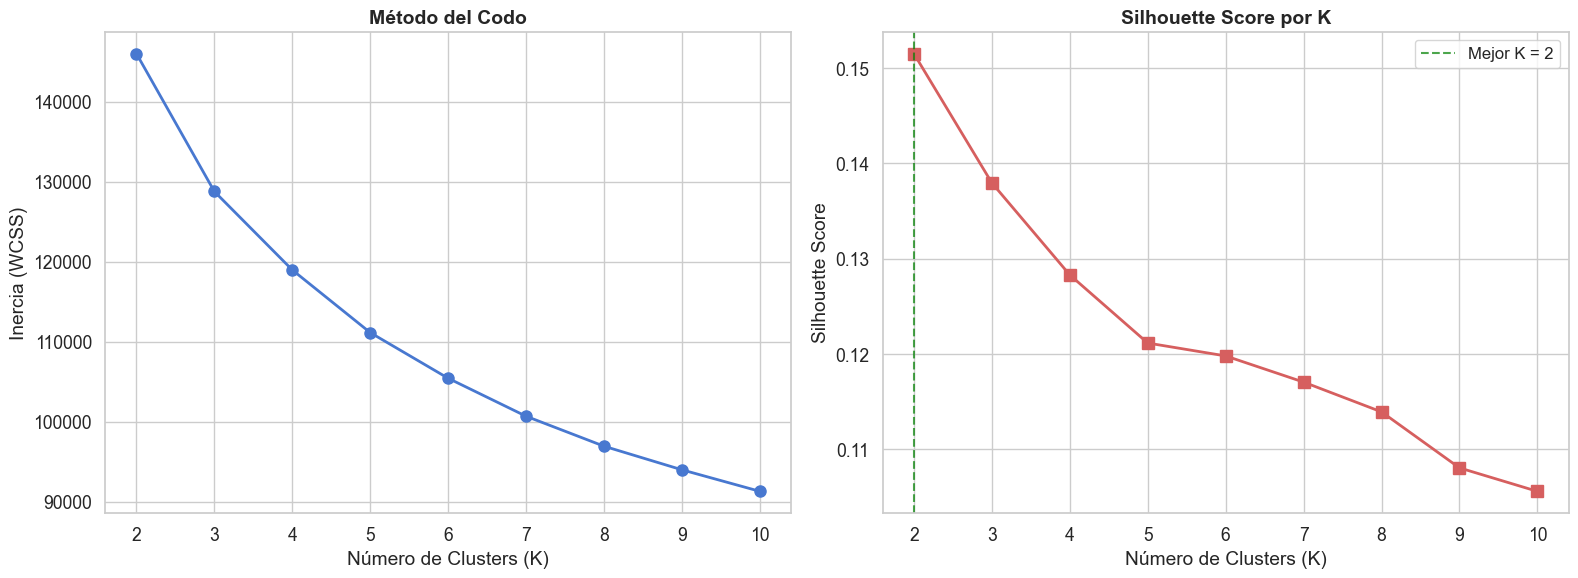


🏆 Mejor K según Silhouette Score: K = 2 (Score = 0.1515)


In [8]:
# ── Gráficos del Codo y Silhouette ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Método del Codo
ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Método del Codo')
ax1.set_xticks(list(K_range))

# Silhouette Score
ax2.plot(list(K_range), silhouettes, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K')
ax2.set_xticks(list(K_range))

# Resaltar el mejor K por silhouette
best_k_idx = np.argmax(silhouettes)
best_k = list(K_range)[best_k_idx]
ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, 
            label=f'Mejor K = {best_k}')
ax2.legend(fontsize=12)

plt.tight_layout()
os.makedirs('../data/08_reporting', exist_ok=True)
plt.savefig('../data/08_reporting/03_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Mejor K según Silhouette Score: K = {best_k} (Score = {silhouettes[best_k_idx]:.4f})')

## 5. K-Means Final — Entrenamiento con el K óptimo

Usamos el K seleccionado para entrenar el modelo final y asignar cada paciente a un cluster.

In [9]:
# ── Elegir K (usamos 4 como balance entre interpretabilidad y granularidad)
# Si el método del codo sugiere otro valor, ajustar aquí
K_FINAL = 4
print(f'🎯 K final seleccionado: {K_FINAL}')
print(f'   (Basado en el análisis del codo y silhouette score)\n')

# ── Entrenar K-Means final ─────────────────────────────────────────────
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
df['CLUSTER'] = kmeans_final.fit_predict(X_pca)

# Distribución de clusters
print('📊 Distribución de pacientes por cluster:')
for cluster_id in sorted(df['CLUSTER'].unique()):
    n = (df['CLUSTER'] == cluster_id).sum()
    pct = n / len(df) * 100
    print(f'   Cluster {cluster_id}: {n:,} pacientes ({pct:.1f}%)')

# Silhouette del modelo final
sil_final = silhouette_score(X_pca, df['CLUSTER'])
print(f'\n📈 Silhouette Score final: {sil_final:.4f}')

🎯 K final seleccionado: 4
   (Basado en el análisis del codo y silhouette score)

📊 Distribución de pacientes por cluster:
   Cluster 0: 2,330 pacientes (23.2%)
   Cluster 1: 2,159 pacientes (21.5%)
   Cluster 2: 2,121 pacientes (21.1%)
   Cluster 3: 3,433 pacientes (34.2%)

📈 Silhouette Score final: 0.1278


## 6. Visualización de Clusters en Espacio PCA (2D)

Proyectamos los datos a 2 dimensiones con PCA para visualizar los clusters. El color representa el cluster asignado y podemos superponer la edad real para validar.

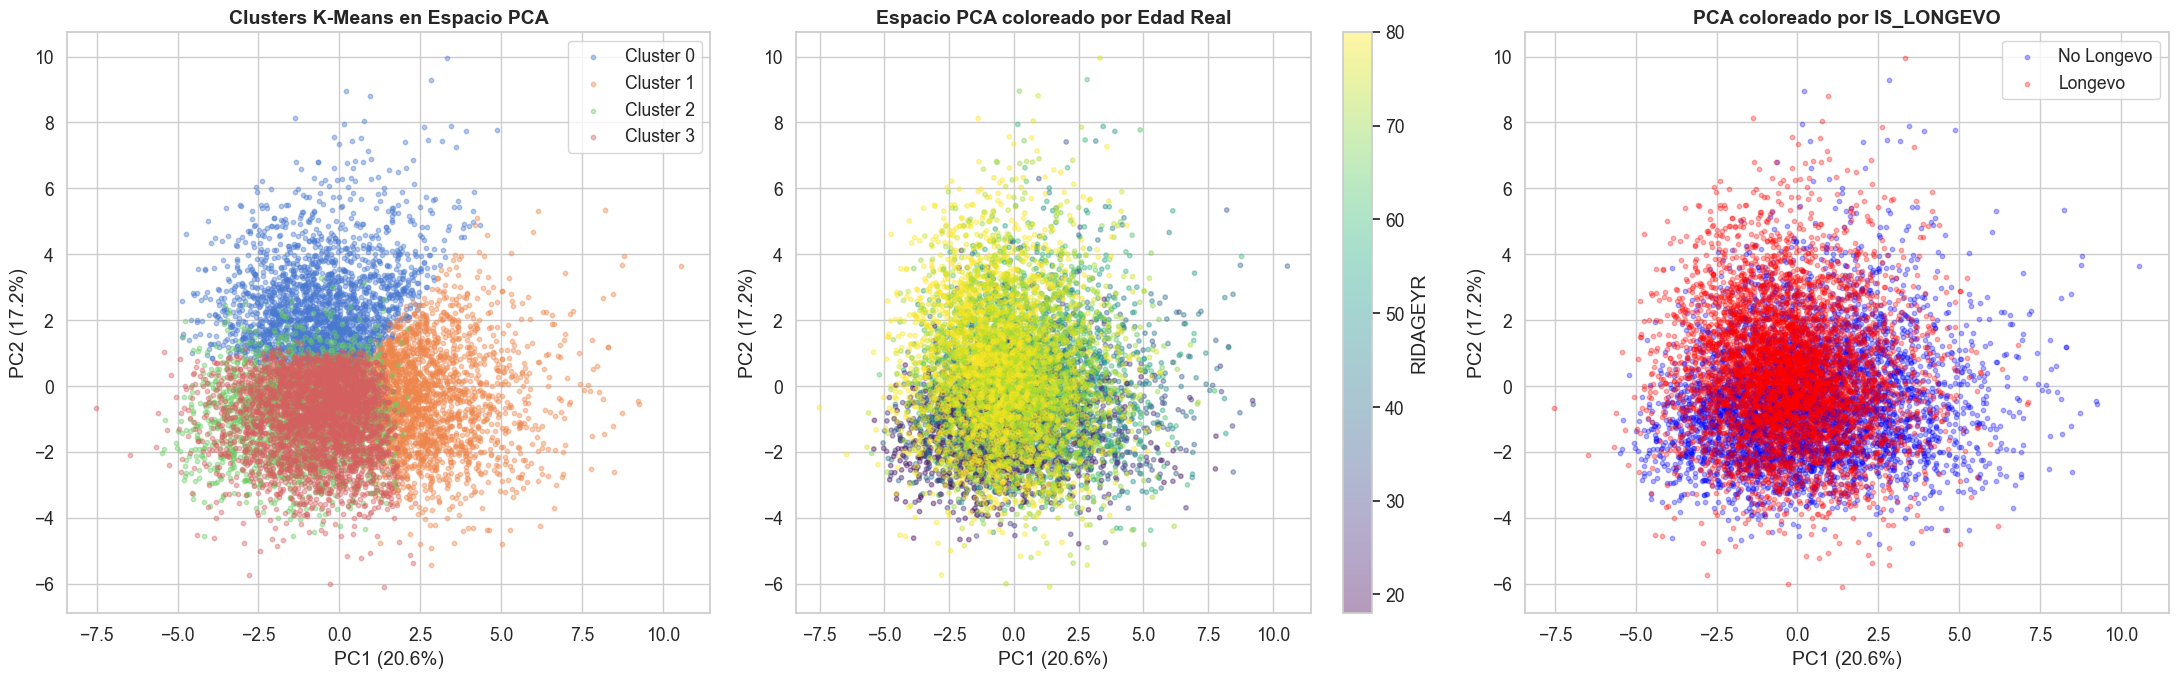

In [10]:
# ── PCA 2D para visualización ──────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

df_pca = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_pca['CLUSTER'] = df['CLUSTER'].values
df_pca['RIDAGEYR'] = df['RIDAGEYR'].values
df_pca['IS_LONGEVO'] = df['IS_LONGEVO'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Clusters
for cluster_id in sorted(df_pca['CLUSTER'].unique()):
    mask = df_pca['CLUSTER'] == cluster_id
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    alpha=0.4, s=10, label=f'Cluster {cluster_id}')
axes[0].set_title('Clusters K-Means en Espacio PCA')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# 2. Colorear por edad
scatter = axes[1].scatter(df_pca['PC1'], df_pca['PC2'],
                          c=df_pca['RIDAGEYR'], cmap='viridis',
                          alpha=0.4, s=10)
axes[1].set_title('Espacio PCA coloreado por Edad Real')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter, ax=axes[1], label='RIDAGEYR')

# 3. Colorear por IS_LONGEVO
for longevo, color, label in [(0, 'blue', 'No Longevo'), (1, 'red', 'Longevo')]:
    mask = df_pca['IS_LONGEVO'] == longevo
    axes[2].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    alpha=0.3, s=10, c=color, label=label)
axes[2].set_title('PCA coloreado por IS_LONGEVO')
axes[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/08_reporting/03_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretación de Centroides — Fenotipos de Salud

Analizamos los centroides de cada cluster para definir qué "tipo de paciente" representa cada grupo. Los valores están escalados (media ≈ 0, σ ≈ 1), excepto `RIDAGEYR` que se mantiene en años reales.

In [11]:
# ── Perfil promedio de cada cluster ────────────────────────────────────
# Usamos las variables más interpretables
vars_interpretacion = ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT',
                       'BPXSY1', 'BPXDI1', 'BPXPLS', 'LBXTC', 'LBXGLU',
                       'DMDHHSIZ', 'INDFMPIR']

# Filtrar solo las que existen
vars_interpretacion = [v for v in vars_interpretacion if v in df.columns]

print('📊 Perfil Promedio de cada Cluster (valores escalados excepto RIDAGEYR):')
perfil = df.groupby('CLUSTER')[vars_interpretacion].mean().round(2)
perfil

📊 Perfil Promedio de cada Cluster (valores escalados excepto RIDAGEYR):


,RIDAGEYR,BMXBMI,BMXWAIST,BMXWT,BMXHT,BPXSY1,BPXDI1,BPXPLS,LBXTC,LBXGLU,DMDHHSIZ,INDFMPIR
CLUSTER,,,,,,,,,,,,
0,70.84,-0.35,-0.33,-0.55,-0.53,1.11,0.48,-0.07,0.29,-0.07,-0.41,-0.14
1,54.86,1.15,1.17,1.36,0.67,0.03,0.45,0.22,-0.02,0.43,0.08,0.12
2,44.09,-0.35,-0.56,-0.47,-0.34,-0.66,-0.05,0.14,-0.02,-0.20,1.25,-0.23
3,64.24,-0.27,-0.16,-0.19,0.15,-0.37,-0.58,-0.17,-0.17,-0.10,-0.54,0.16


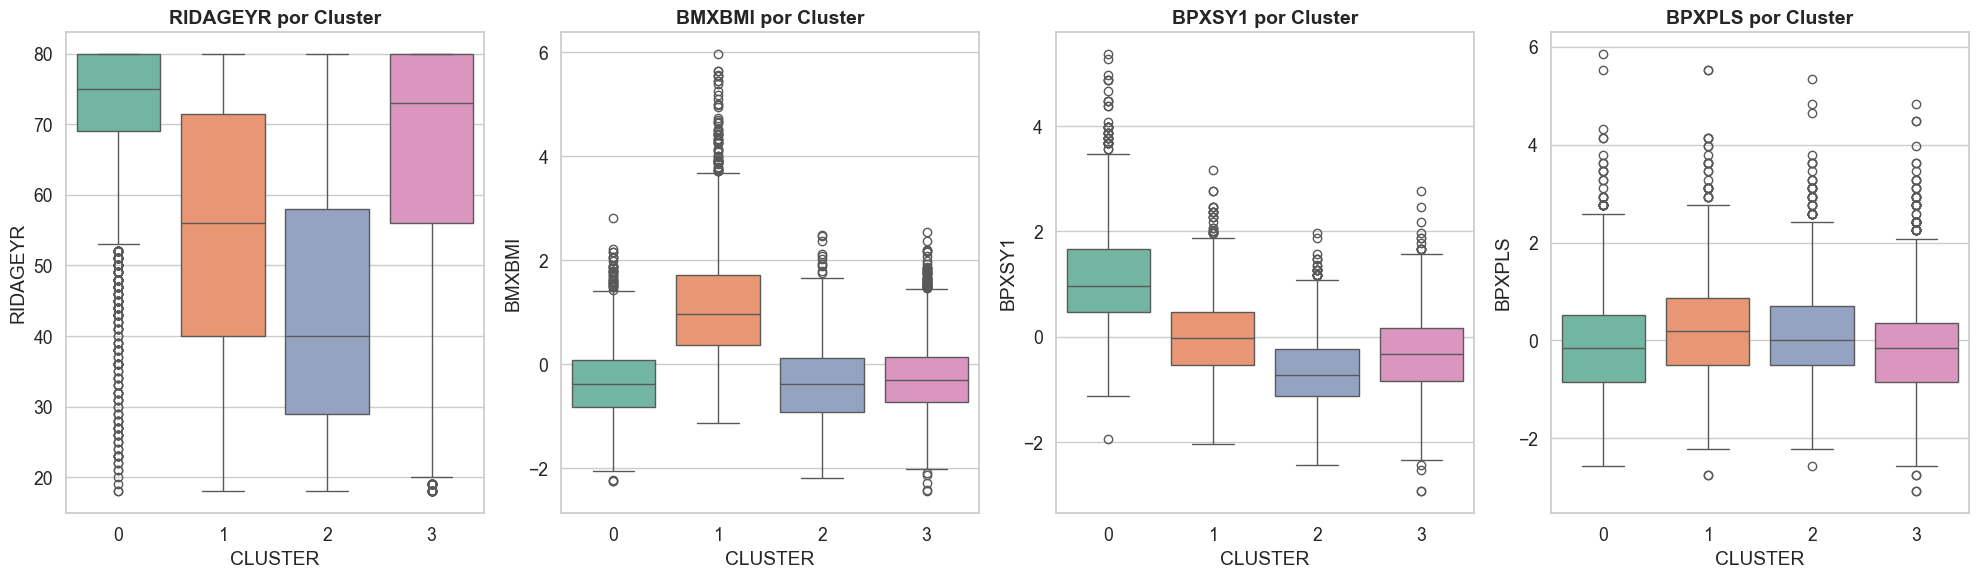

In [12]:
# ── Boxplots para comparar clusters ────────────────────────────────────
vars_box = ['RIDAGEYR', 'BMXBMI', 'BPXSY1', 'BPXPLS']
vars_box = [v for v in vars_box if v in df.columns]

fig, axes = plt.subplots(1, len(vars_box), figsize=(5*len(vars_box), 6))

for i, var in enumerate(vars_box):
    sns.boxplot(data=df, x='CLUSTER', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} por Cluster')

plt.tight_layout()
plt.savefig('../data/08_reporting/03_cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Proporción de longevos por cluster ─────────────────────────────────
print('📊 Proporción de Longevos (IS_LONGEVO=1) por Cluster:')
print('   (Esto valida si los clusters capturan información de longevidad)\n')

for cluster_id in sorted(df['CLUSTER'].unique()):
    subset = df[df['CLUSTER'] == cluster_id]
    n_total = len(subset)
    n_longevo = (subset['IS_LONGEVO'] == 1).sum()
    pct = n_longevo / n_total * 100 if n_total > 0 else 0
    edad_media = subset['RIDAGEYR'].mean()
    print(f'   Cluster {cluster_id}: {n_longevo:,}/{n_total:,} longevos ({pct:.1f}%) — Edad media: {edad_media:.1f} años')

📊 Proporción de Longevos (IS_LONGEVO=1) por Cluster:
   (Esto valida si los clusters capturan información de longevidad)

   Cluster 0: 1,724/2,330 longevos (74.0%) — Edad media: 70.8 años
   Cluster 1: 736/2,159 longevos (34.1%) — Edad media: 54.9 años
   Cluster 2: 377/2,121 longevos (17.8%) — Edad media: 44.1 años
   Cluster 3: 2,166/3,433 longevos (63.1%) — Edad media: 64.2 años


## 8. Conclusiones

### Hallazgos clave:
1. **PCA** logra capturar la mayor parte de la varianza en relativamente pocos componentes, lo que confirma que muchas variables clínicas están correlacionadas.
2. **K-Means** identifica fenotipos de salud diferenciados basándose únicamente en biomarcadores, sin conocer la edad ni la longevidad.
3. La **proporción de longevos varía entre clusters**, lo que sugiere que algunos perfiles metabólicos están más asociados a la longevidad que otros.
4. Estos clusters pueden usarse como **segmentos de pacientes** en la app de Edad Biológica.

---
*Siguiente: Notebook 04 — Clasificación Supervisada (IS_LONGEVO)*